In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
from config import images_path

The data csv file is generated from a different program that handles downloading and filtering images from derpibooru.

In [21]:
df = pd.read_csv('data/image_data.csv')
df['tags'] = df['tags'].str.split('|')

# Counting the tag frequency across all images

def count_tags(tag_col: pd.Series):
    tag_freq = {}

    for tags in tag_col:
        for tag in tags:
            if tag not in tag_freq:
                tag_freq[tag] = 1
            else:
                tag_freq[tag] += 1

    tag_freq = pd.DataFrame(
        list(tag_freq.items()),
        columns=['tag', 'freq']
    ).sort_values('freq', ascending=False)

    tag_freq['p'] = tag_freq['freq'] / len(tag_col)
    return tag_freq

In [22]:
# Viewing the most frequent tags that might be chosen for the model to predict
pd.set_option('display.max_rows', 100)
pd.set_option('display.precision', 2)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.2f}'.format)

tag_freq = count_tags(df['tags'])
tag_freq[tag_freq['p'] >= 0.038]

,tag,freq,p
19,pony,183535,1.00
23,solo,183531,1.00
20,safe,183522,1.00
8,female,156476,0.85
11,g4,145776,0.79
14,mare,108494,0.59
83,simple background,66813,0.36
5,cute,50987,0.28
61,unicorn,50591,0.28
33,smiling,48055,0.26


From tags that are present in at least %5 of images, 30 are chosen that seem reasonable for the model to predict.

In [23]:
to_predict = (
    'female', 'male',
    'unicorn', 'pegasus', 'earth pony', 'alicorn',
    'simple background', 'monochrome',
    'clothes', 'wings', 'horn', 'chest fluff', 'ear fluff', 'hat', 'jewelry', 'food', 'foal',
    'looking at you', 'smiling', 'open mouth', 'blushing', 'sitting', 'raised hoof', 'eyes closed',
    'twilight sparkle', 'fluttershy', 'rainbow dash', 'pinkie pie', 'rarity', 'applejack'
)

len(to_predict)

30

In [ ]:
from transformers import AutoModel, AutoImageProcessor
from skmultilearn.model_selection import iterative_train_test_split
from PIL import Image
import numpy as np
from torch.utils.data import Dataset, Subset
from torch import nn
import torch
import os
import utils

In [25]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

ViT: nn.Module = AutoModel.from_pretrained('facebook/dinov2-base').to(device)
ViT.requires_grad_(False)
ViT.eval()

print(device)

Loading weights: 100%|██████████| 223/223 [00:00<00:00, 16086.16it/s]

cuda


In [ ]:
class Horses(Dataset):
    def __init__(self):
        self.df = df.copy()
        self.df['tags'] = self.df['tags'].map(lambda tags: utils.multi_hot(tags, to_predict))
        self.processor = AutoImageProcessor.from_pretrained('facebook/dinov2-base')
    
    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]
        image = Image.open(images_path / f'{row['id']}.{row['image_format']}')

        return self.processor(image)['pixel_values'][0], row['tags']

ds = Horses()
df['tags'] = ds.df['tags'].map(
    lambda enc: [
        to_predict[i]
        for i, present in zip(range(len(to_predict)), enc) if present
    ]
)
len(ds)

183536

In [27]:
y = np.stack(ds.df['tags'].to_numpy())

if os.path.exists('data/indices.npz'):
    with np.load('data/indices.npz') as stored:
        idx_train = stored['train']
        idx_test = stored['test']
    
    y_train = y[idx_train]
    y_test = y[idx_test]
else:
    idx = ds.df.index.to_numpy().reshape(-1, 1)

    idx_train, y_train, idx_test, y_test = iterative_train_test_split(idx, y, 0.1)

    idx_train = idx_train.reshape(-1)
    idx_test = idx_test.reshape(-1)
    np.savez(
        'data/indices.npz',
        train=idx_train,
        test=idx_test,
    )

In [28]:
ds_train = Subset(ds, idx_train.tolist())
ds_test = Subset(ds, idx_test.tolist())

In [29]:
# Train distribution
count_tags(df.loc[idx_train, 'tags'])

,tag,freq,p
0,female,140159,0.86
2,simple background,59588,0.37
1,unicorn,45217,0.28
6,smiling,42750,0.26
8,pegasus,41258,0.25
13,earth pony,38387,0.24
3,clothes,32158,0.20
12,looking at you,28380,0.17
15,alicorn,24068,0.15
9,wings,23308,0.14


In [30]:
# Test distribution
count_tags(df.loc[idx_test, 'tags'])

,tag,freq,p
0,female,16317,0.78
10,simple background,7225,0.34
1,pegasus,5816,0.28
6,unicorn,5374,0.26
3,smiling,5305,0.25
15,earth pony,4306,0.21
7,clothes,4124,0.20
26,looking at you,4003,0.19
2,wings,3335,0.16
22,alicorn,3048,0.15


In [ ]:
if os.path.exists('data/base_embeddings.npy'):
    embeddings = np.load('data/base_embeddings.npy')
else:
    embeddings = torch.zeros((len(ds), 768), device=device)

    with torch.no_grad():
        for i, (X, _) in enumerate(ds):
            X = X.to(device, non_blocking=True).unsqueeze(0)
            embeddings[i] = ViT(X).last_hidden_state[0, 0]
            print(round((i + 1) * 100 / len(ds), 1), end='\r')

    embeddings = embeddings.cpu()
    np.save('data/base_embeddings.npy', embeddings)

X_train = embeddings[idx_train]
X_test = embeddings[idx_test]

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

In [41]:
model = OneVsRestClassifier(LogisticRegression(max_iter=500, class_weight='balanced'))
model.fit(X_train, y_train)

,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.",LogisticRegre... max_iter=500)
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes`one-vs-rest problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: 0.20 `n_jobs` default changed from 1 to None",None
,"verbose verbose: int, default=0The verbosity level, if non zero, progress messages are printed.Below 50, the output is sent to stderr. Otherwise, the output is sentto stdout. The frequency of the messages increases with the verbositylevel, reporting all iterations at 10. See :class:`joblib.Parallel` formore details... versionadded:: 1.1",0
Name,Type,Value
"classes_ classes_: array, shape = [`n_classes`]Class labels.","ndarray[int64](30,)","[ 0, 1, 2,...,27,28,29]"
estimators_ estimators_: list of `n_classes` estimatorsEstimators used for predictions.,list,"[LogisticRegre... max_iter=500), LogisticRegre... max_iter=500), LogisticRegre... max_iter=500), LogisticRegre... max_iter=500), ...]"
label_binarizer_ label_binarizer_: LabelBinarizer objectObject used to transform multiclass labels to binary labels andvice-versa.,LabelBinarizer,LabelBinarize...e_output=True)
multilabel_ multilabel_: booleanWhether a OneVsRestClassifier is a multilabel classifier.,bool,True
n_classes_ n_classes_: intNumber of classes.,int,30
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 0.24,int,768
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'


In [43]:
utils.evaluate(model.predict(X_test), y_test, to_predict)

,tag,f1,precision,recall,tp,fp,tn,fn,count
0,female,0.81,0.88,0.75,12205,1731,2934,4112,16317.00
6,simple background,0.79,0.70,0.90,6518,2805,10952,707,7225.00
7,monochrome,0.72,0.57,0.96,878,654,19410,40,918.00
3,pegasus,0.70,0.62,0.82,4753,2948,12218,1063,5816.00
24,twilight sparkle,0.67,0.54,0.90,1985,1698,17069,230,2215.00
2,unicorn,0.66,0.56,0.79,4258,3306,12302,1116,5374.00
4,earth pony,0.66,0.54,0.83,3586,3036,13640,720,4306.00
8,clothes,0.65,0.54,0.79,3265,2727,14131,859,4124.00
25,fluttershy,0.64,0.50,0.89,1422,1432,17959,169,1591.00
5,alicorn,0.61,0.48,0.84,2553,2771,15163,495,3048.00


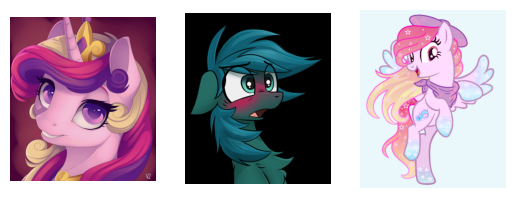

          unicorn:  0.89  0
          alicorn:  0.87  0
   looking at you:  0.80  1
             horn:  0.79  0
          smiling:  0.72  1
           female:  0.70  1
          jewelry:  0.64  0
        ear fluff:  0.55  0

simple background:  0.91  1
       earth pony:  0.79  1
             male:  0.75  1
         blushing:  0.63  1
      chest fluff:  0.55  1
          pegasus:  0.54  0
     rainbow dash:  0.50  0

          clothes:  0.81  0
           female:  0.71  0
simple background:  0.61  1
            wings:  0.61  1
          smiling:  0.60  0
      raised hoof:  0.58  0
         blushing:  0.57  0
       open mouth:  0.55  0
       earth pony:  0.54  0
          jewelry:  0.54  0
          pegasus:  0.54  1
   looking at you:  0.51  0


In [143]:
import matplotlib.pyplot as plt
from matplotlib.axes import Axes

np.random.seed(1)
idx_obs = np.random.choice(idx_test, 3, False)

rows = df.loc[idx_obs]
imgs = [Image.open(images_path / f'{row['id']}.{row['image_format']}') for _, row in rows.iterrows()]

fig, axis = plt.subplots(1, 3)
axis: list[Axes]

for ax, img in zip(axis, imgs):
    ax.imshow(img)
    ax.axis(False)

preds = model.predict_proba(embeddings[idx_obs])
labels = y[idx_obs].astype(int)
idx_sorted = preds.argsort()[:, ::-1]

label_names = np.array(to_predict)

preds = [
    '\n'.join([
        f'{label_name + ':  ':>20}{p:.2f}  {label}'
        for p, label_name, label in
        zip(preds[o, idx], label_names[idx], labels[o, idx])
        if p > 0.5
    ])
    for o, idx in enumerate(idx_sorted)
]

plt.show()
print('\n\n'.join(preds))